In [12]:
import pandas as pd
# to visualize stock
import mplfinance as mpf

In [ ]:


浙江仙通(SH:603239) ✅
浙江仙通(SH603239) bollinger
金诚信(SH603979) ✅

中材科技(SZ002080)
星帅尔(SZ:002860) ✅
紫江企业(SH:600210)？
中微公司(SH:688012)✅
中远海特(SH:600428)

In [172]:
stock_symbol = 'SH600428'
start_date = pd.to_datetime('2023-01-15') # inclusive
end_date = pd.to_datetime('2025-11-07') # exclusive
bundle_name = 'cn-daily-bundle'
close_col='close'

In [173]:
print(f'https://xueqiu.com/S/{stock_symbol}')

https://xueqiu.com/S/SH600428


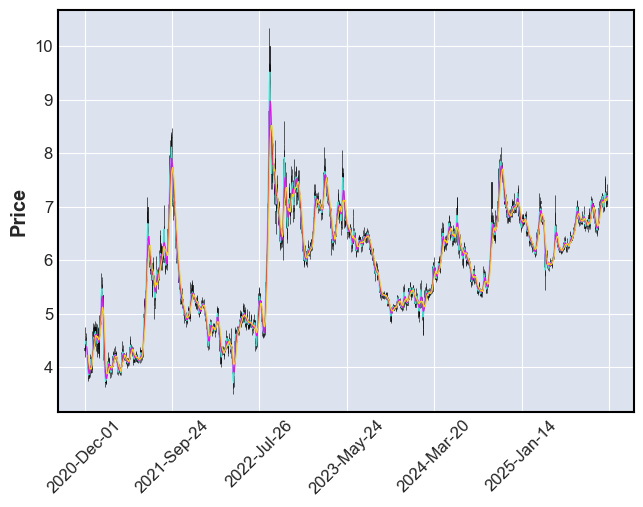

In [174]:

# daily = pd.read_csv(f'/Users/yilin/Documents/Projects_stock/stock_analysis/zipline_data/daily/{stock_symbol}.csv',index_col=0,parse_dates=True)

daily = pd.read_csv(f'/Users/yilin/Documents/Projects_stock/stock_analysis/data/tushare_kline/daily/{stock_symbol}.csv',index_col=0,parse_dates=True)
daily.index.name = 'Date'
mpf.plot(daily,type='candle',mav=(3,6,9))

In [175]:
daily

,high,low,open,close,adjclose,volume,amount
Date,,,,,,,
2020-12-01,4.37,4.20,4.33,4.36,27.57,523493.70,225149.052
2020-12-02,4.75,4.30,4.35,4.60,29.09,932632.75,423883.416
2020-12-03,4.53,4.35,4.50,4.36,27.57,559350.62,247223.074
2020-12-04,4.65,4.35,4.42,4.52,28.58,590285.80,265136.627
2020-12-07,4.56,4.35,4.56,4.38,27.70,446995.75,197155.062
...,...,...,...,...,...,...,...
2025-11-03,7.30,7.06,7.24,7.16,7.28,442821.42,316284.975
2025-11-04,7.20,7.00,7.15,7.06,7.16,423639.64,300319.747
2025-11-05,7.16,7.01,7.02,7.11,7.06,329455.24,233157.352


In [176]:
# Benchmark
max(daily['close'])*0.8/(min(daily.loc[daily.close>0,'close'])*1.2)

1.7680365296803653

In [177]:
# load calendar. Use from trading_calendars import get_calendar or import exchange_calendars as xcals will report error
from zipline.utils.calendar_utils import get_calendar

# Momentum-Based/Trend-Following Strategies

## Rolling Window Mean Strategy

In [178]:
# from zipline.data.bundles import register, custom_quandl
# register('custom-csvdir-bundle',custom_quandl.ingest, calendar_name='XSHG')

Equity(323 [SH600428])


Start date,2023-01-16
End date,2025-11-07
Total months,32
,Backtest
Annual return,-11.544%
Cumulative returns,-28.18%
Annual volatility,25.336%
Sharpe ratio,-0.36
Calmar ratio,-0.28
Stability,0.20
Max drawdown,-41.157%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,41.16,2023-03-09,2025-07-07,NaT,NaN
1,5.24,2023-02-06,2023-02-27,2023-03-03,20
2,0.52,2023-03-06,2023-03-07,2023-03-09,4
3,0.10,2023-02-02,2023-02-03,2023-02-06,3
4,NaN,NaT,NaT,NaT,NaN


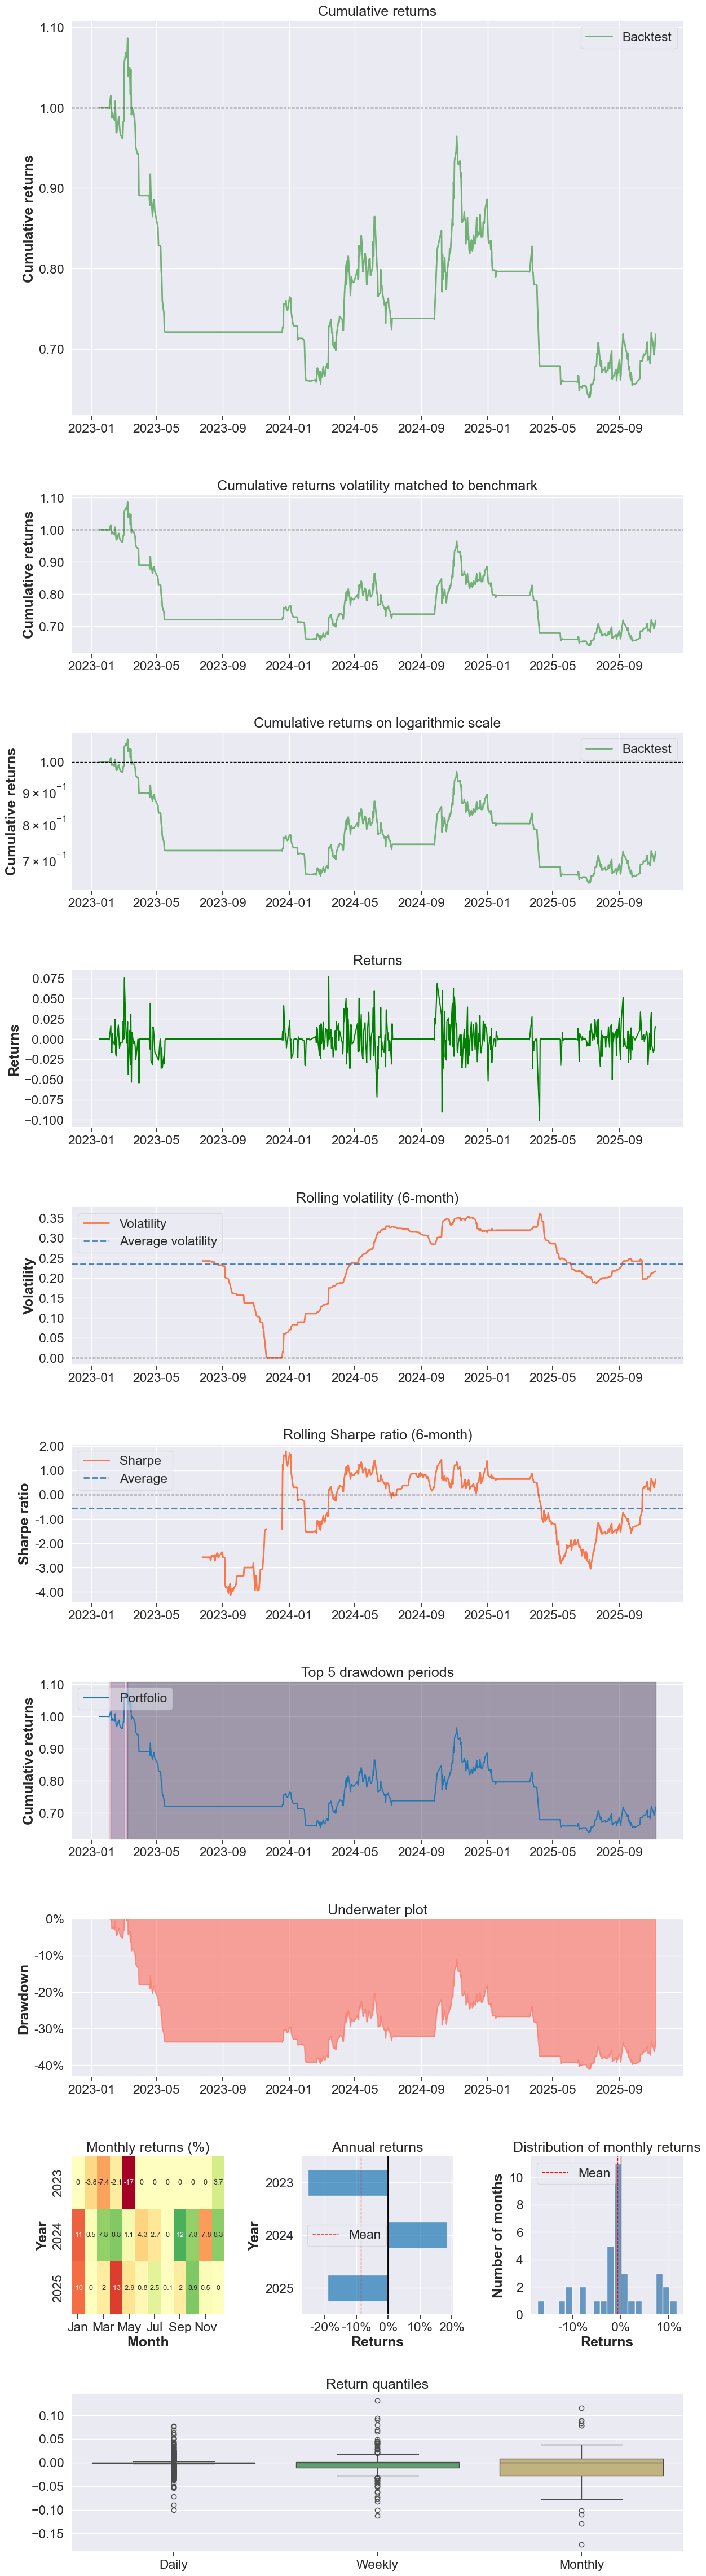

In [179]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbol, set_commission
from zipline.finance.commission import PerTrade
import pandas as pd
import pyfolio as pf



import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    # context.stock = symbol('AAPL')
    context.stock = symbol(stock_symbol)

    
    print(context.stock)
    context.rolling_window = 90
    set_commission(PerTrade(cost=5)) 


def handle_data(context, data): 
    price_hist = data.history(context.stock, "close", context.rolling_window, "1d")           
    order_target_percent(context.stock, 1.0 if price_hist[-1] > price_hist.mean() else 0.0) 

def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    

# start_date = pd.Timestamp('2000-1-1')
# end_date = pd.Timestamp('2018-1-1')

# from zipline.utils.calendar_utils import XNYSExchangeCalendar
# start = pd.Timestamp(from_date, tz=pytz.UTC)
# cal = XNYSExchangeCalendar(start=start_date)

results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name
                       )



## Simple Moving Averages Strategy

Start date,2023-01-16
End date,2025-11-07
Total months,32
,Backtest
Annual return,-0.081%
Cumulative returns,-0.219%
Annual volatility,24.118%
Sharpe ratio,0.12
Calmar ratio,-0.00
Stability,0.06
Max drawdown,-26.072%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,26.07,2023-05-09,2024-02-05,2024-04-15,245
1,25.16,2024-06-07,2025-02-06,NaT,NaN
2,12.26,2023-03-17,2023-04-03,2023-04-20,25
3,9.51,2023-04-20,2023-05-05,2023-05-09,14
4,7.23,2024-05-13,2024-05-23,2024-06-06,19


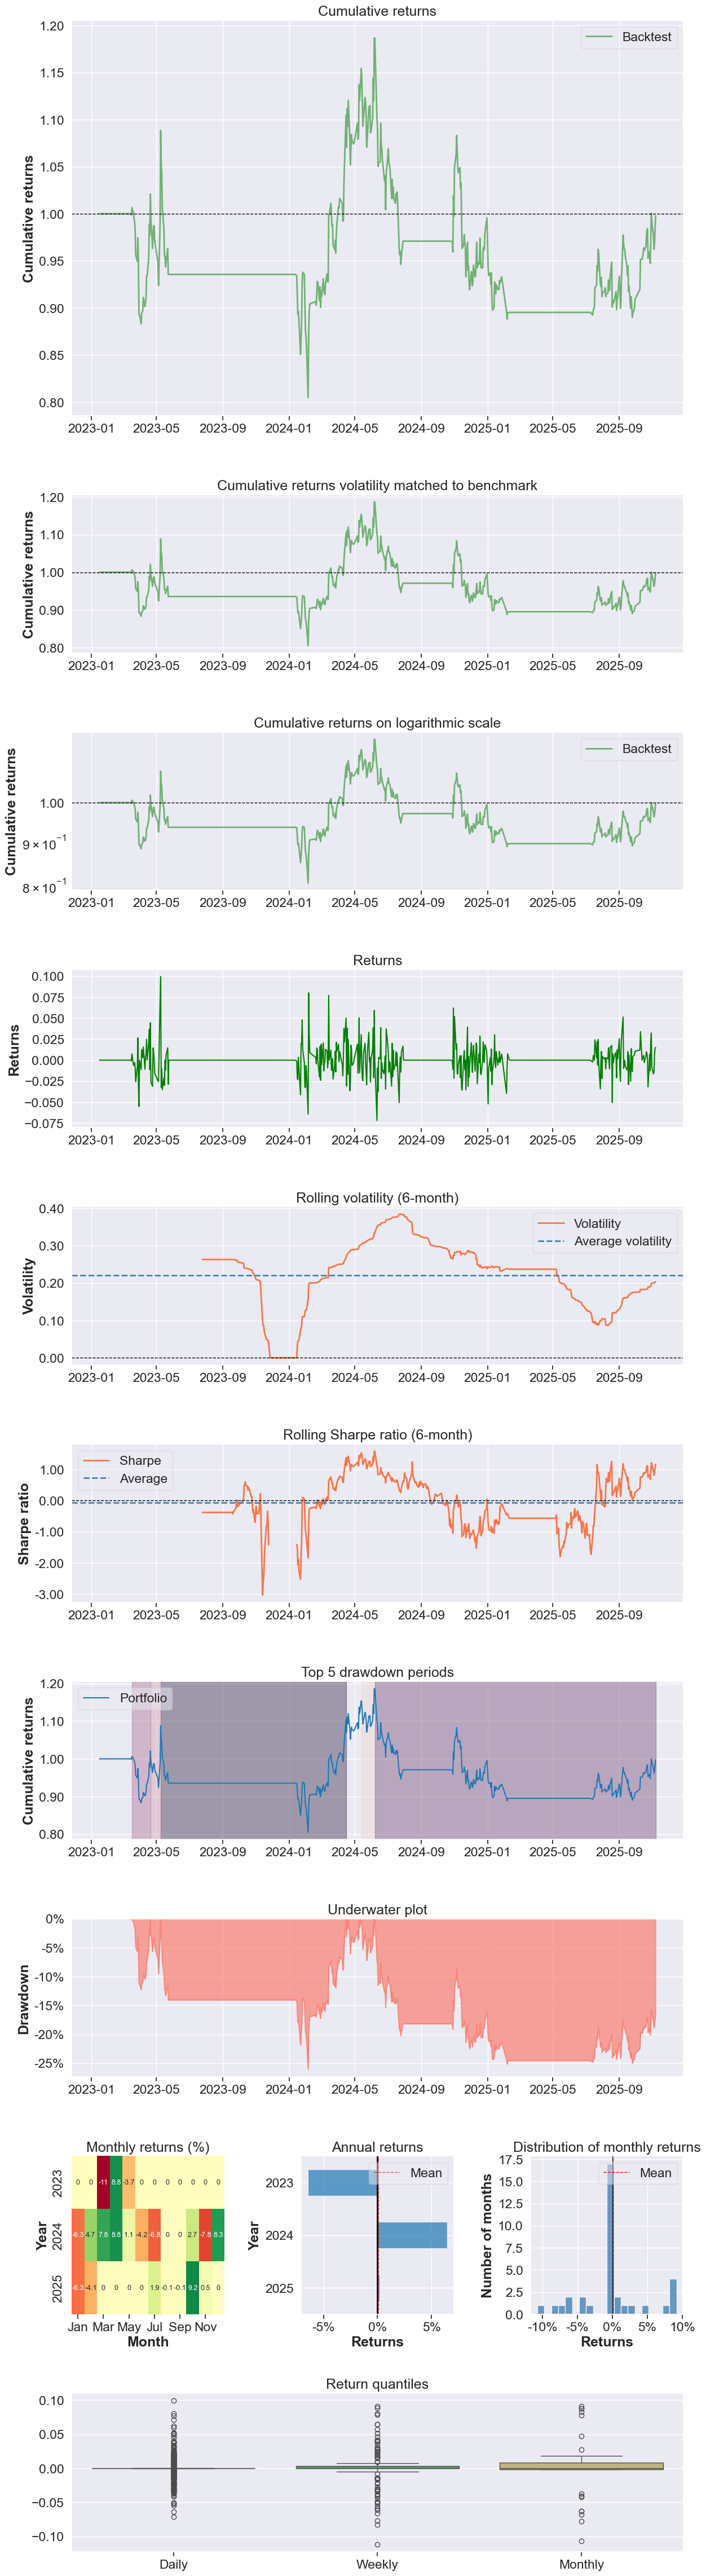

In [180]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbol, set_commission
from zipline.finance.commission import PerTrade
import pandas as pd
import pyfolio as pf

import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    # context.stock = symbol('AAPL')
    context.stock = symbol(stock_symbol)
    context.rolling_window = 90 
    set_commission(PerTrade(cost=5))     

def handle_data(context, data): 
    price_hist = data.history(context.stock, "close", context.rolling_window, "1d")          
    
    rolling_mean_short_term = price_hist.rolling(window=45, center=False).mean()
    rolling_mean_long_term = price_hist.rolling(window=90, center=False).mean()
    
    if rolling_mean_short_term[-1] > rolling_mean_long_term[-1]:
        order_target_percent(context.stock, 1.0)     
    elif rolling_mean_short_term[-1] < rolling_mean_long_term[-1]:
        order_target_percent(context.stock, 0.0)     

def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    
# start_date = pd.to_datetime('2000-1-1', utc=True)
# end_date = pd.to_datetime('2018-1-1', utc=True)
    
# results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
#                         capital_base = 10000, data_frequency = 'daily', bundle ='quandl')

results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name)

## Exponentially-Weighted Moving Averages Strategy

Start date,2023-01-16
End date,2025-11-07
Total months,32
,Backtest
Annual return,-12.962%
Cumulative returns,-31.244%
Annual volatility,25.406%
Sharpe ratio,-0.42
Calmar ratio,-0.30
Stability,0.38
Max drawdown,-43.086%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,43.09,2023-03-09,2025-09-22,NaT,NaN
1,5.23,2023-02-06,2023-02-27,2023-03-03,20
2,0.83,2023-02-02,2023-02-03,2023-02-06,3
3,0.52,2023-03-06,2023-03-07,2023-03-09,4
4,0.10,2023-01-31,2023-02-01,2023-02-02,3


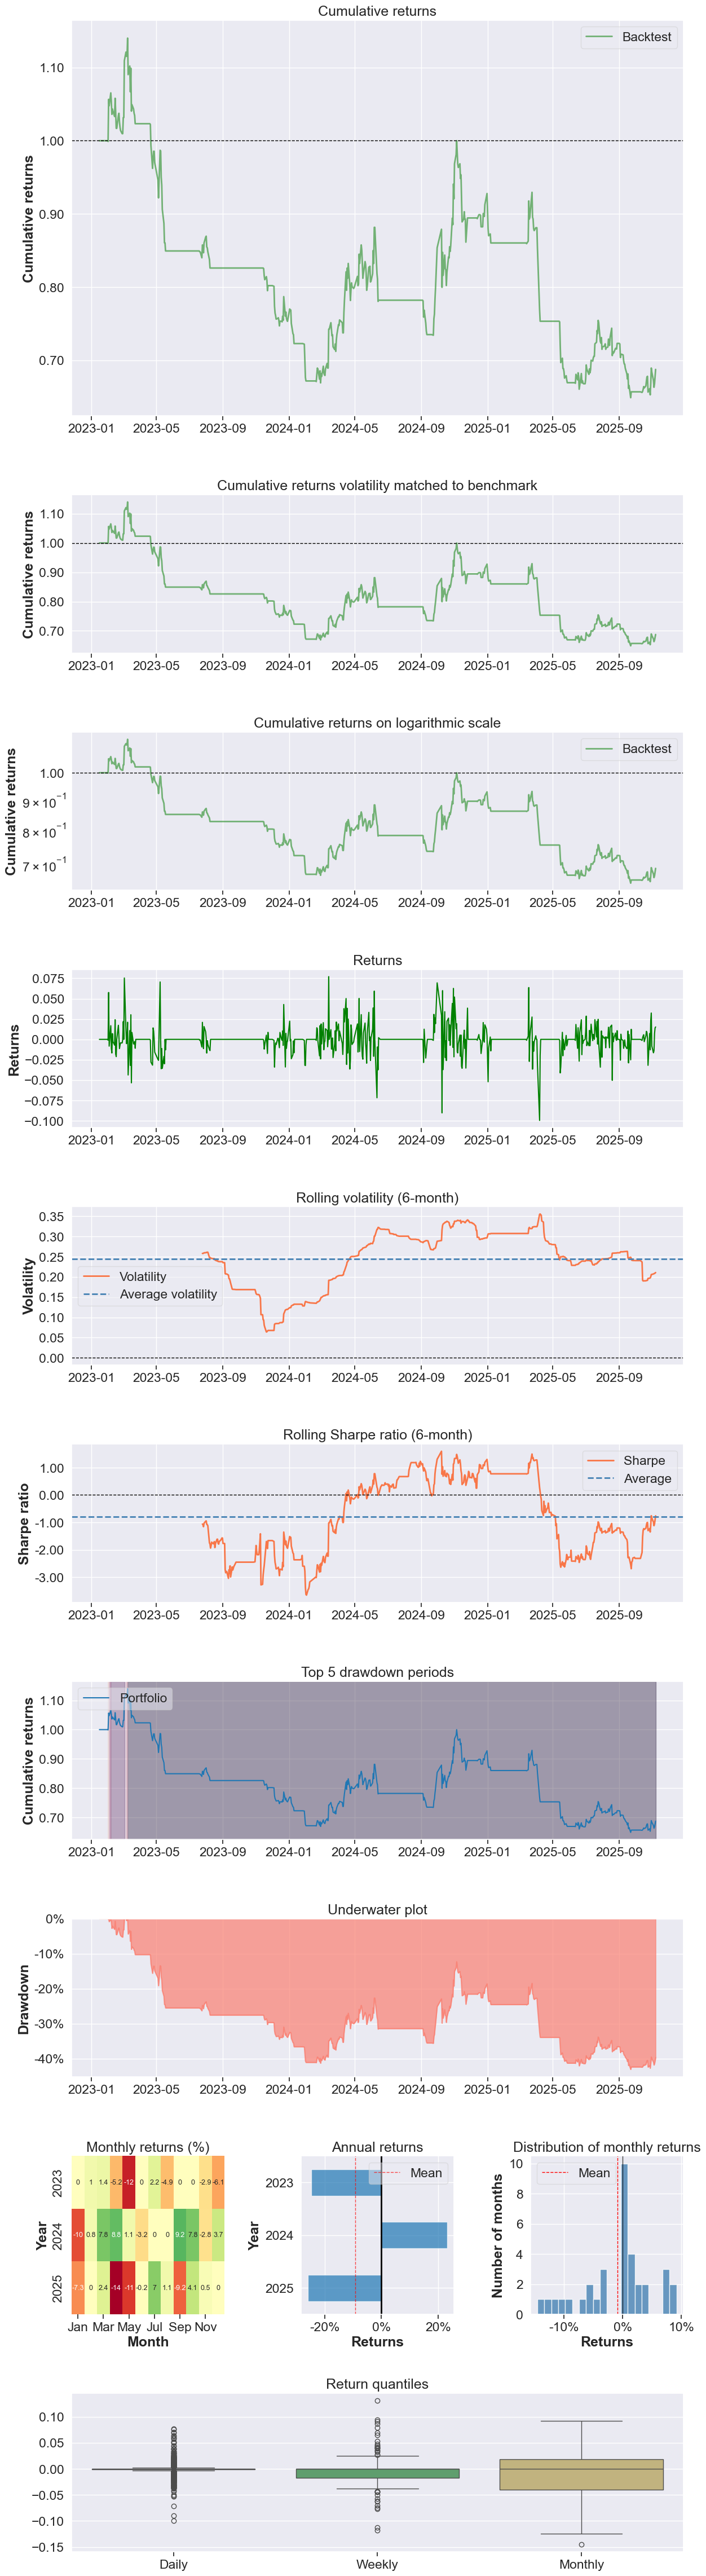

In [181]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbol, set_commission
from zipline.finance.commission import PerTrade
import pandas as pd
import pyfolio as pf

import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    # context.stock = symbol('AAPL')
    context.stock = symbol(stock_symbol)
    context.rolling_window = 90
    set_commission(PerTrade(cost=5))     

def handle_data(context, data): 
    price_hist = data.history(context.stock, "close", context.rolling_window, "1d")          
    
    rolling_mean_short_term = price_hist.ewm(span=5,adjust=True,ignore_na=True).mean()
    rolling_mean_long_term = price_hist.ewm(span=30,adjust=True,ignore_na=True).mean()
    
    if rolling_mean_short_term[-1] > rolling_mean_long_term[-1]:
        order_target_percent(context.stock, 1.0)     
    elif rolling_mean_short_term[-1] < rolling_mean_long_term[-1]:
        order_target_percent(context.stock, 0.0)     

def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    
# start_date = pd.to_datetime('2000-1-1', utc=True)
# end_date = pd.to_datetime('2018-1-1', utc=True)
    
# results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
        # capital_base = 10000, data_frequency = 'daily', bundle ='quandl')

results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name)


## RSI Strategy

In [182]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbol, set_commission
from zipline.finance.commission import PerTrade
# load calendar. Use from trading_calendars import get_calendar or import exchange_calendars as xcals will report error
from zipline.utils.calendar_utils import get_calendar

import pandas as pd
import pyfolio as pf
from stockstats import StockDataFrame as sdf


import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    # context.stock = symbol('AAPL')
    context.stock = symbol(stock_symbol)
    context.rolling_window = 20
    set_commission(PerTrade(cost=5))     

def handle_data(context, data): 
    price_hist = data.history(context.stock, ["open", "high", "low","close"], context.rolling_window, "1d")             
    
    stock=sdf.retype(price_hist)   

    rsi = stock.get('rsi_12')
    
    if rsi[-1] > 90:
        order_target_percent(context.stock, 0.0)     
    elif rsi[-1] < 10:
        order_target_percent(context.stock, 1.0)   
        
def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    
# start_date = pd.to_datetime('2015-1-1', utc=True)
# end_date = pd.to_datetime('2018-1-1', utc=True)
    
# results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
# capital_base = 10000, data_frequency = 'daily', bundle ='quandl')

results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name)



AttributeError: 'DataFrame' object has no attribute 'amount'

## MACD Crossover Strategy

Start date,2023-01-16
End date,2025-11-07
Total months,32
,Backtest
Annual return,-4.463%
Cumulative returns,-11.592%
Annual volatility,25.021%
Sharpe ratio,-0.06
Calmar ratio,-0.13
Stability,0.05
Max drawdown,-35.086%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,35.09,2023-03-09,2024-02-28,2025-05-14,570
1,15.68,2025-07-24,2025-11-04,NaT,NaN
2,11.56,2025-05-14,2025-06-19,2025-07-24,52
3,0.56,2023-03-06,2023-03-07,2023-03-09,4
4,0.10,2023-03-02,2023-03-03,2023-03-06,3


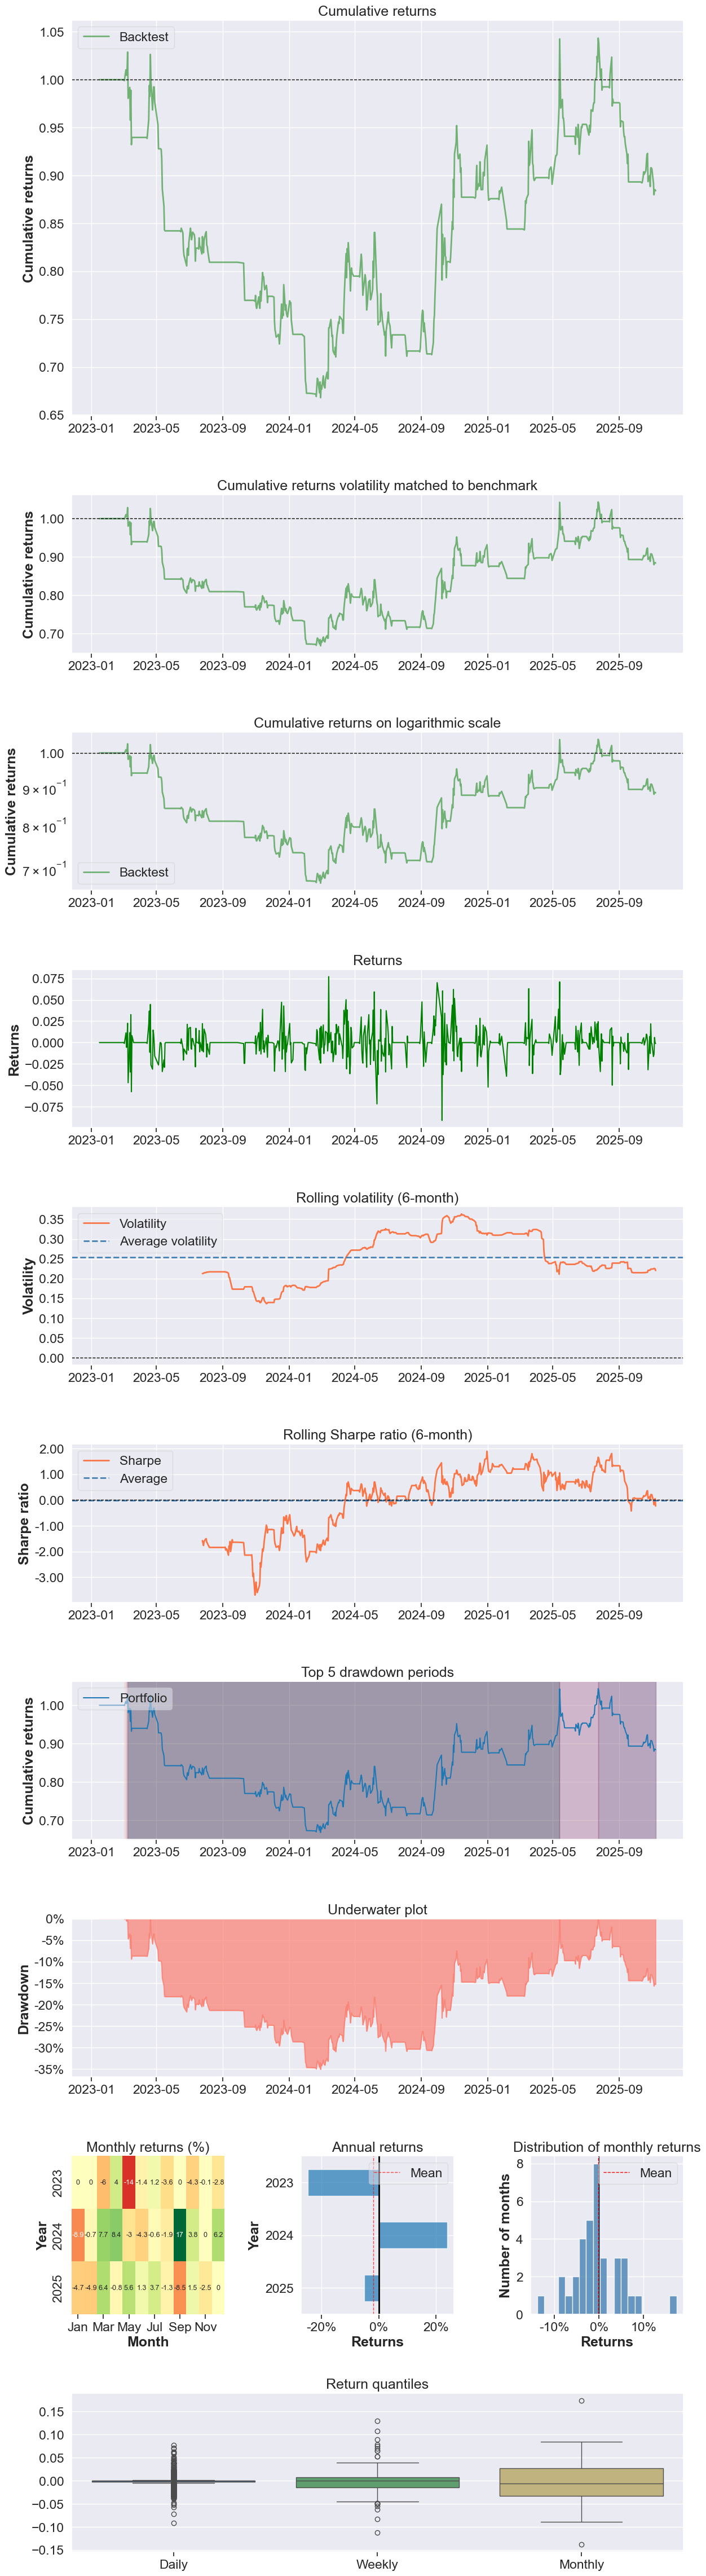

In [183]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbol, set_commission
from zipline.finance.commission import PerTrade
import pandas as pd
import pyfolio as pf
from stockstats import StockDataFrame as sdf

import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    # context.stock = symbol('AAPL')
    context.stock = symbol(stock_symbol)
    context.rolling_window = 20
    set_commission(PerTrade(cost=5))     

def handle_data(context, data): 
    price_hist = data.history(context.stock, ["open", "high", "low","close"], context.rolling_window, "1d")             
    
    stock=sdf.retype(price_hist)   

    signal = stock['macds']
    macd   = stock['macd'] 
    
    if macd[-1] > signal[-1] and macd[-2] <= signal[-2]:
        order_target_percent(context.stock, 1.0)     
    elif macd[-1] < signal[-1] and macd[-2] >= signal[-2]:
        order_target_percent(context.stock, 0.0)   
        
def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    
# start_date = pd.to_datetime('2015-1-1', utc=True)
# end_date = pd.to_datetime('2018-1-1', utc=True)
    
# results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, capital_base = 10000, data_frequency = 'daily', bundle ='quandl')

results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name)


## RSI + MACD Strategy

Start date,2023-01-16
End date,2025-11-07
Total months,32
,Backtest
Annual return,2.928%
Cumulative returns,8.098%
Annual volatility,24.32%
Sharpe ratio,0.24
Calmar ratio,0.11
Stability,0.55
Max drawdown,-27.485%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,27.49,2023-03-09,2024-02-05,2024-04-17,290
1,17.25,2024-04-19,2024-08-23,2024-09-30,117
2,16.88,2024-10-08,2025-03-05,2025-05-14,157
3,9.75,2025-05-14,2025-05-23,NaT,NaN
4,1.69,2024-04-17,2024-04-18,2024-04-19,3


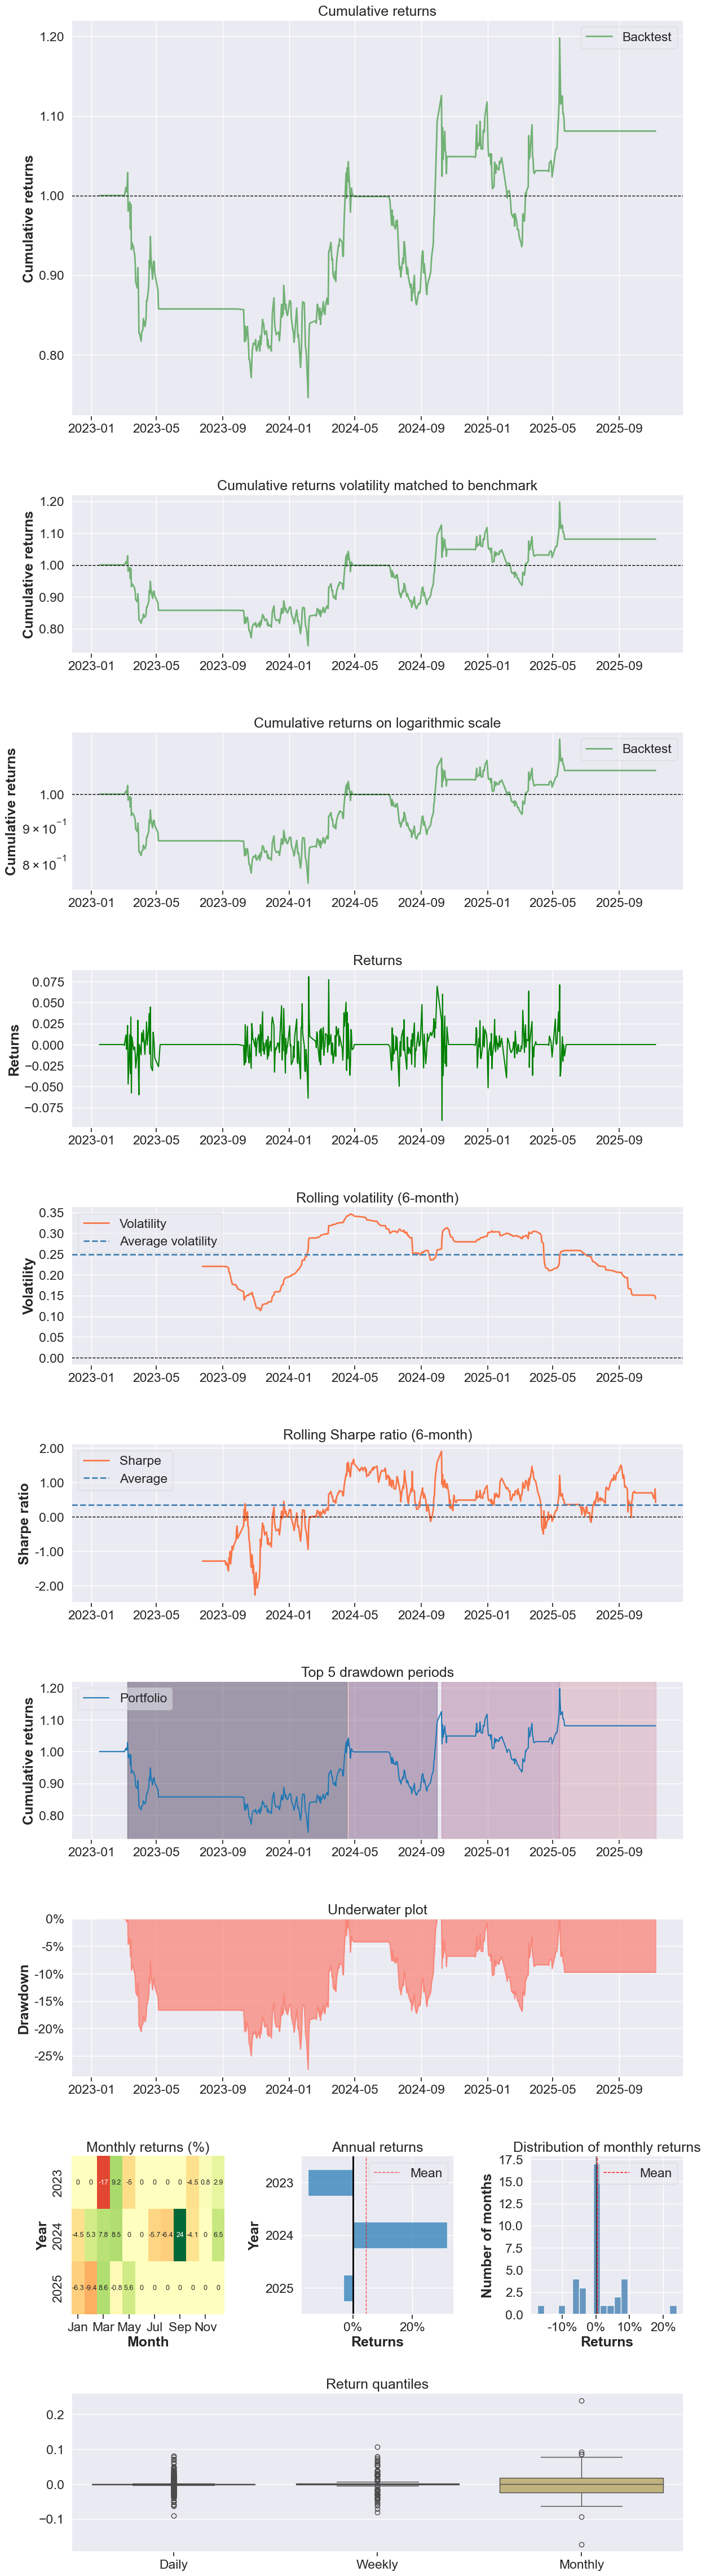

In [184]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbol, set_commission
from zipline.finance.commission import PerTrade
import pandas as pd
import pyfolio as pf
from stockstats import StockDataFrame as sdf

import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    # context.stock = symbol('AAPL')
    context.stock = symbol(stock_symbol)
    context.rolling_window = 20
    set_commission(PerTrade(cost=5))     

def handle_data(context, data): 
    price_hist = data.history(context.stock, ["open", "high", "low","close"], context.rolling_window, "1d")             
    
    stock=sdf.retype(price_hist)   

    rsi = stock.get('rsi_12')
       
    signal = stock['macds']
    macd   = stock['macd'] 
        
    if rsi[-1] < 50 and macd[-1] > signal[-1] and macd[-2] <= signal[-2]:
        order_target_percent(context.stock, 1.0)     
    elif rsi[-1] > 50 and macd[-1] < signal[-1] and macd[-2] >= signal[-2]:
        order_target_percent(context.stock, 0.0)   
        
def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    
# start_date = pd.to_datetime('2015-1-1', utc=True)
# end_date = pd.to_datetime('2018-1-1', utc=True)
    
# results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, capital_base = 10000, data_frequency = 'daily', bundle ='quandl')
results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name)


## Triple Exponential Average (TRIX) Strategy

Start date,2023-01-16
End date,2025-11-07
Total months,32
,Backtest
Annual return,-9.369%
Cumulative returns,-23.315%
Annual volatility,21.36%
Sharpe ratio,-0.35
Calmar ratio,-0.22
Stability,0.60
Max drawdown,-42.225%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,42.23,2023-03-09,2025-03-05,NaT,NaN
1,0.52,2023-03-06,2023-03-07,2023-03-09,4
2,0.10,2023-02-27,2023-02-28,2023-03-01,3
3,NaN,NaT,NaT,NaT,NaN
4,NaN,NaT,NaT,NaT,NaN


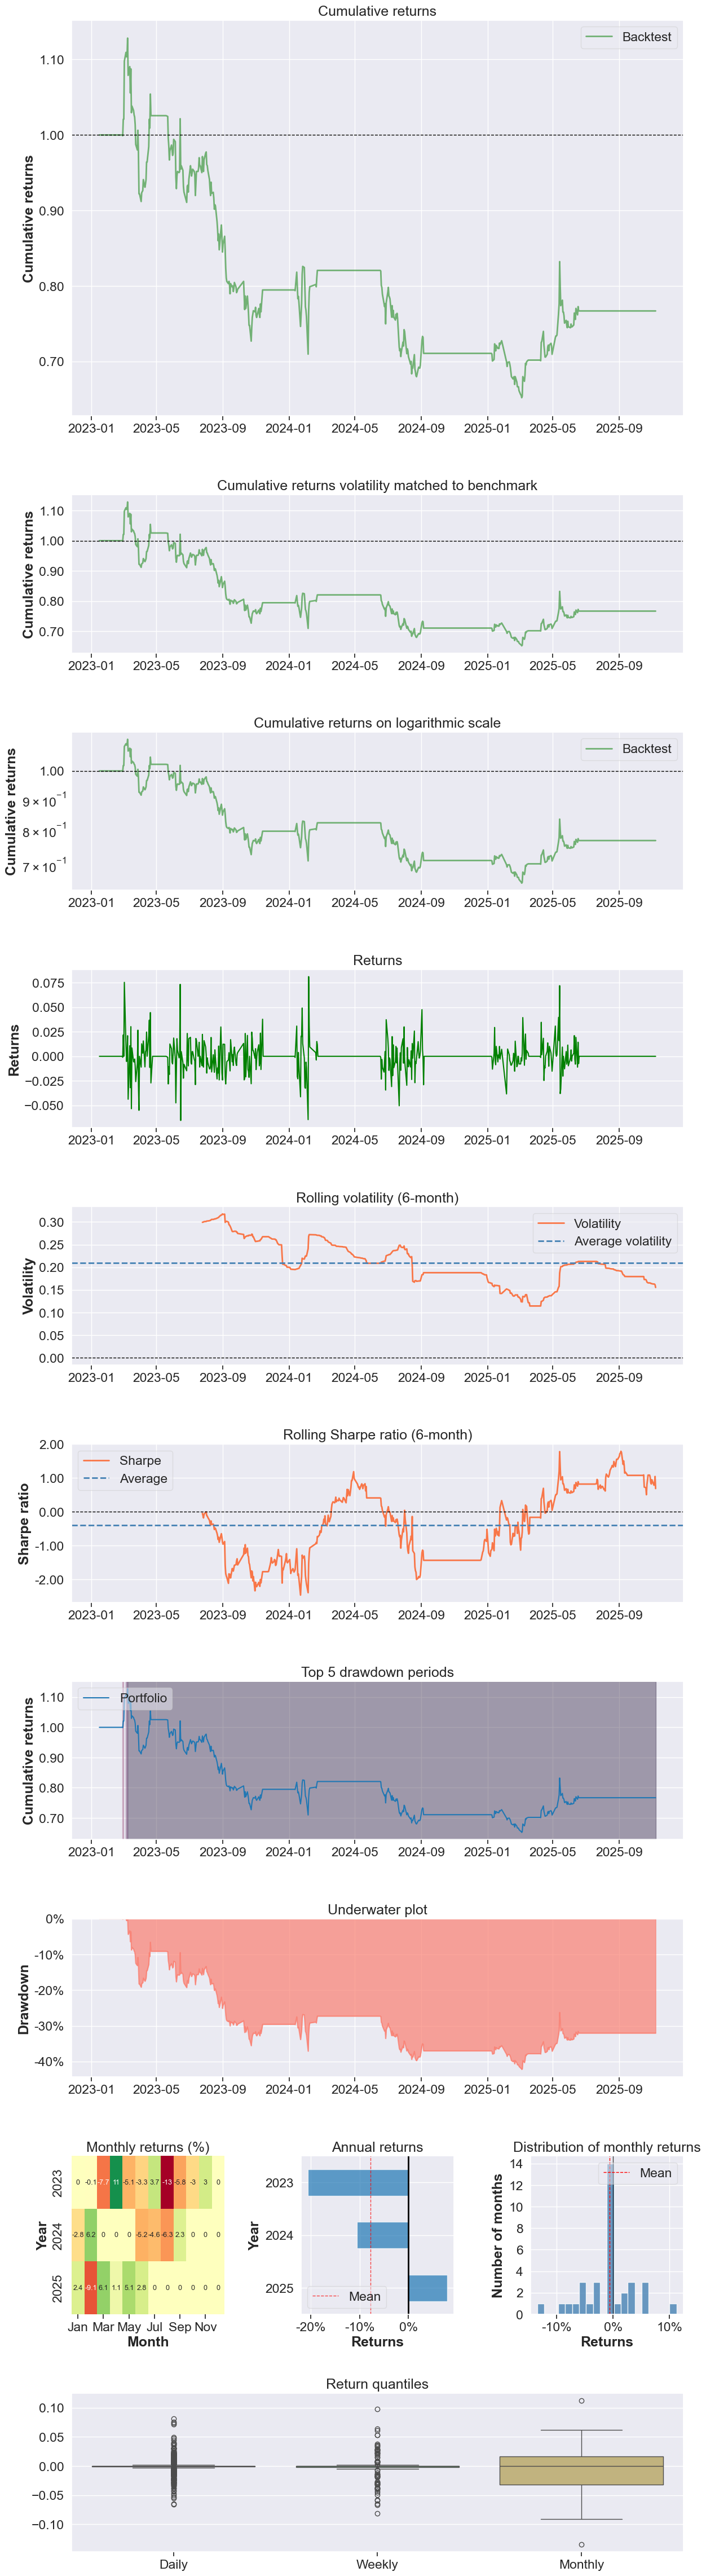

In [185]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbol, set_commission
from zipline.finance.commission import PerTrade
import pandas as pd
import pyfolio as pf
from stockstats import StockDataFrame as sdf

import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    # context.stock = symbol('AAPL')
    context.stock = symbol(stock_symbol)
    context.rolling_window = 20
    set_commission(PerTrade(cost=5))     

def handle_data(context, data): 
    price_hist = data.history(context.stock, ["open", "high", "low","close"], context.rolling_window, "1d")             
    
    stock=sdf.retype(price_hist)   

    trix = stock.get('trix')
    
    if trix[-1] > 0 and trix[-2] < 0:
        order_target_percent(context.stock, 0.0)     
    elif trix[-1] < 0 and trix[-2] > 0:
        order_target_percent(context.stock, 1.0)   
        
def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    
# start_date = pd.to_datetime('2015-1-1', utc=True)
# end_date = pd.to_datetime('2018-1-1', utc=True)
    
# results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, capital_base = 10000, data_frequency = 'daily', bundle ='quandl')

results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name)


## Williams %R Strategy

In [186]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbol, set_commission
from zipline.finance.commission import PerTrade
import pandas as pd
import pyfolio as pf
from stockstats import StockDataFrame as sdf

import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    # context.stock = symbol('AAPL')
    context.stock = symbol(stock_symbol)
    context.rolling_window = 20
    set_commission(PerTrade(cost=5))     

def handle_data(context, data): 
    price_hist = data.history(context.stock, ["open", "high", "low","close"], context.rolling_window, "1d")             
    
    stock=sdf.retype(price_hist)   

    wr = stock.get('wr_6')
    # print(wr)
    if wr[-1] < 10:
        order_target_percent(context.stock, 0.0)     
    elif wr[-1] > 90:
        order_target_percent(context.stock, 1.0)   
        
def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    
# start_date = pd.to_datetime('2015-1-1', utc=True)
# end_date = pd.to_datetime('2018-1-1', utc=True)
    
# results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
# capital_base = 10000, data_frequency = 'daily', bundle ='quandl')

results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name)

# AttributeError: 'DataFrame' object has no attribute 'amount' error, because no stock buy in based on the criteria

AttributeError: 'DataFrame' object has no attribute 'amount'

# Mean Reversion Strategies

## Bollinger Band Trading Strategy

Start date,2023-01-16
End date,2025-11-07
Total months,32
,Backtest
Annual return,7.275%
Cumulative returns,20.865%
Annual volatility,15.834%
Sharpe ratio,0.52
Calmar ratio,0.29
Stability,0.44
Max drawdown,-25.01%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,25.01,2023-04-20,2023-10-23,2025-01-27,463
1,10.73,2025-01-27,2025-03-05,2025-04-14,56
2,4.58,2025-04-14,2025-04-17,2025-05-12,21
3,1.20,2023-03-30,2023-04-03,2023-04-04,4
4,1.14,2023-04-18,2023-04-19,2023-04-20,3


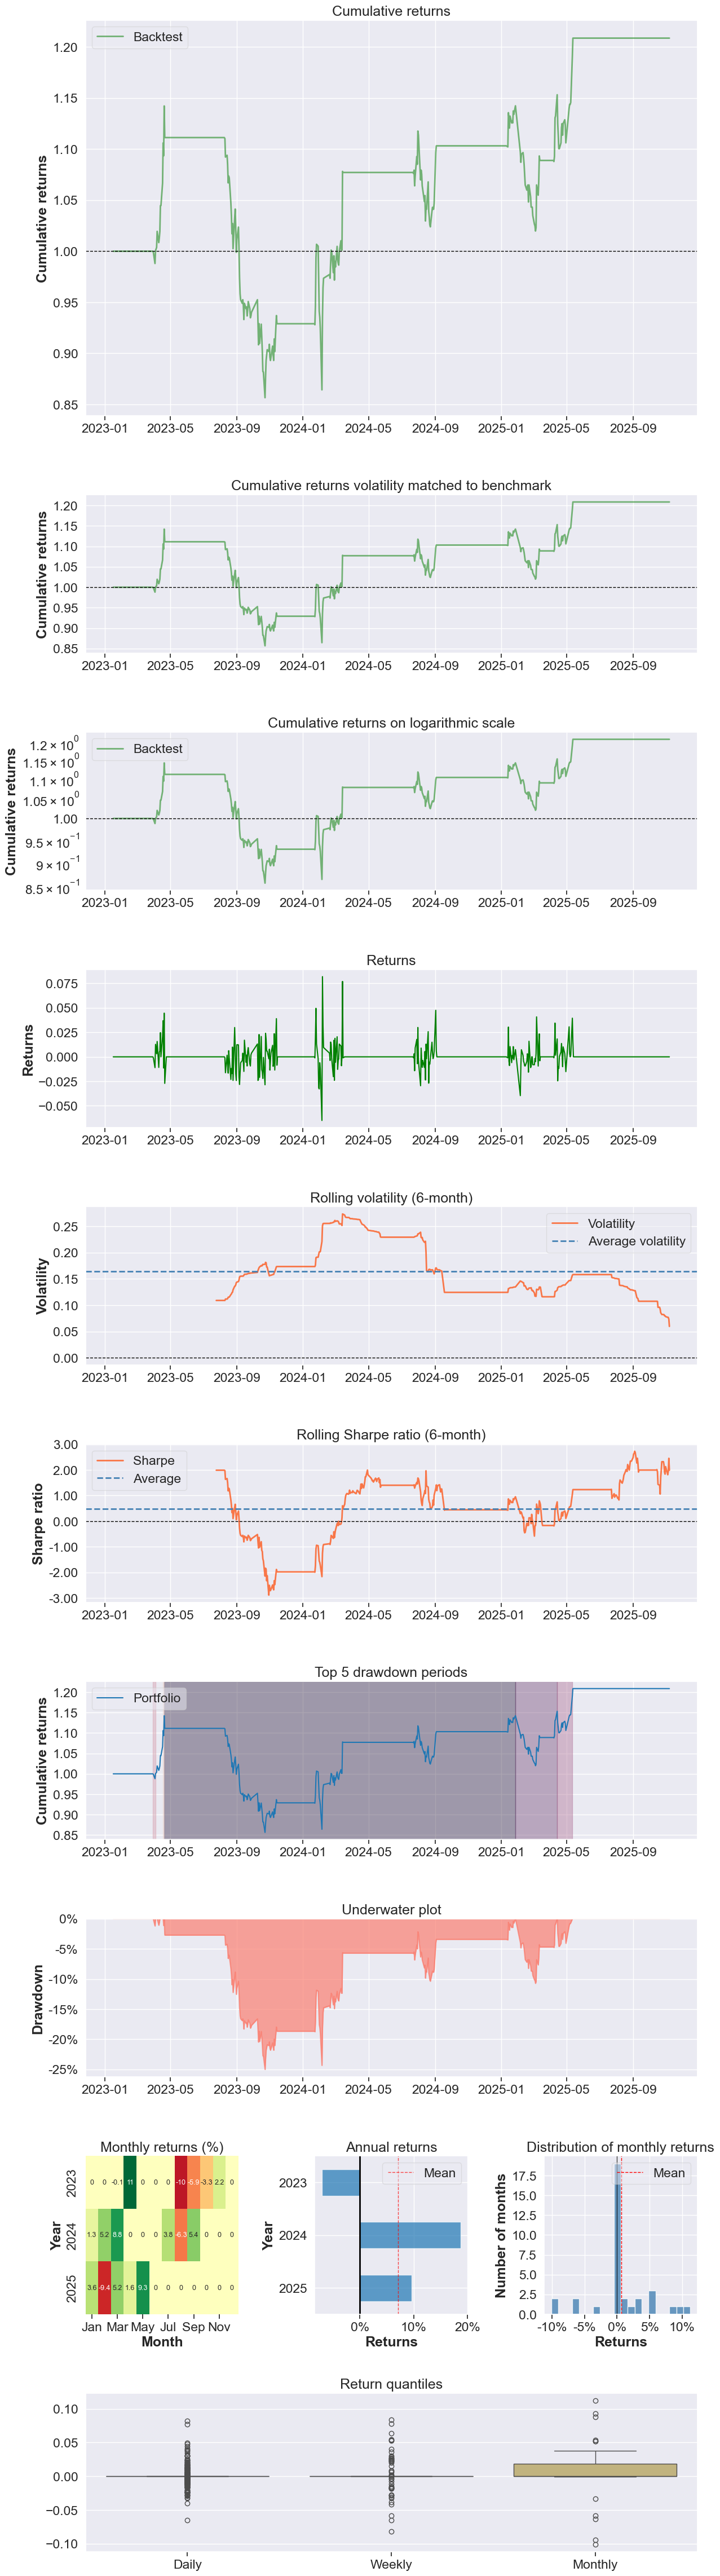

In [187]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbol, set_commission
from zipline.finance.commission import PerTrade
import pandas as pd
import pyfolio as pf

import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    # context.stock = symbol('AAPL')
    context.stock = symbol(stock_symbol)
    context.rolling_window = 20 
    set_commission(PerTrade(cost=5))     

def handle_data(context, data): 
    price_hist = data.history(context.stock, "close", context.rolling_window, "1d")          
    
    middle_base_line = price_hist.mean()
    std_line =  price_hist.std()
    lower_band = middle_base_line - 2 * std_line
    upper_band = middle_base_line + 2 * std_line
   
    if price_hist[-1] < lower_band:
        order_target_percent(context.stock, 1.0)     
    elif price_hist[-1] > upper_band:
        order_target_percent(context.stock, 0.0)     

def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    
# start_date = pd.to_datetime('2000-1-1', utc=True)
# end_date = pd.to_datetime('2018-1-1', utc=True)
    
# results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, capital_base = 10000, data_frequency = 'daily', bundle ='quandl')

results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name)


In [ ]:
results.to_csv('/Users/yilin/Documents/Projects_stock/stock_analysis/result.csv', index=False, encoding='utf-8')

## Pairs-Trading Strategy

In [ ]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbol, set_commission
from zipline.finance.commission import PerTrade
import pandas as pd
import pyfolio as pf
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint


import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    context.stock_x = symbol('PEP')
    context.stock_y = symbol('KO')
    context.rolling_window = 500
    set_commission(PerTrade(cost=5))       
    context.i = 0
    
def handle_data(context, data):   
    context.i += 1
    if context.i < context.rolling_window:
        return
    
    try:
        x_price = data.history(context.stock_x, "close", context.rolling_window, "1d")
        x = np.log(x_price)
        
        y_price = data.history(context.stock_y, "close", context.rolling_window, "1d")
        y = np.log(y_price)

        _, p_value, _  = coint(x, y)
        if p_value < .9:
            return
        
        slope, intercept = sm.OLS(y, sm.add_constant(x, prepend=True)).fit().params
        
        spread = y - (slope * x + intercept)
        zscore = (spread[-1] - spread.mean()) / spread.std()    
        
        if -1 < zscore < 1:
            return

        side = np.copysign(0.5, zscore)
        order_target_percent(context.stock_y, -side * 100 / y_price[-1])
        order_target_percent(context.stock_x,  side * slope * 100 / x_price[-1])    
    except:
        pass

def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    
# start_date = pd.to_datetime('2015-1-1', utc=True)
# end_date = pd.to_datetime('2018-01-01', utc=True)
    
# results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, capital_base = 10000, data_frequency = 'daily', bundle ='quandl')

results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name)


# Mathematical Model Based Strategies

## Minimization of Portfolio Volatility Strategy with Monthly Trading

In [ ]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbol, set_commission, schedule_function, date_rules, time_rules
from zipline.finance.commission import PerTrade
import pandas as pd
import pyfolio as pf
from scipy.optimize import minimize
import numpy as np

import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    context.stocks = [symbol('DIS'),symbol('WMT'),symbol('DOW'),symbol('CRM'),symbol('NKE'),symbol('HD'),symbol('V'),symbol('MSFT'),symbol('MMM'),symbol('CSCO'),symbol('KO'),symbol('AAPL'),symbol('HON'),symbol('JNJ'),symbol('TRV'),symbol('PG'),symbol('CVX'),symbol('VZ'),symbol('CAT'),symbol('BA'),symbol('AMGN'),symbol('IBM'),symbol('AXP'),symbol('JPM'),symbol('WBA'),symbol('MCD'),symbol('MRK'),symbol('GS'),symbol('UNH'),symbol('INTC')]
    context.rolling_window = 200
    set_commission(PerTrade(cost=5))
    schedule_function(handle_data, date_rules.month_end(), time_rules.market_open(hours=1))
    
def minimum_vol_obj(wo, cov):
    w = wo.reshape(-1, 1)
    sig_p = np.sqrt(np.matmul(w.T, np.matmul(cov, w)))[0, 0]
    return sig_p

def handle_data(context, data): 
    n_stocks = len(context.stocks)
    prices = None
    
    for i in range(n_stocks):
        price_history = data.history(context.stocks[i], "close", context.rolling_window, "1d")
        
        price = np.array(price_history)
        if prices is None:
            prices = price
        else:
            prices = np.c_[prices, price]
    
    rets = prices[1:,:]/prices[0:-1, :]-1.0
    mu = np.mean(rets, axis=0)
    cov = np.cov(rets.T)    
           
    w0 = np.ones(n_stocks) / n_stocks
    
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}, {'type': 'ineq', 'fun': lambda w: w})
    TOL = 1e-12    
    res = minimize(minimum_vol_obj, w0, args=cov, method='SLSQP', constraints=cons, tol=TOL, options={'disp': False})
    
    if not res.success:
        return;
    
    w = res.x
    
    for i in range(n_stocks):
        order_target_percent(context.stocks[i], w[i])    

def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    
# start_date = pd.to_datetime('2010-1-1', utc=True)
# end_date = pd.to_datetime('2018-1-1', utc=True)
    
# results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, capital_base = 10000, data_frequency = 'daily', bundle ='quandl')

results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name)


## Maximum Sharpe Ratio Strategy with Monthly Trading 

In [ ]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbols, set_commission, schedule_function, date_rules, time_rules
from zipline.finance.commission import PerTrade
import pandas as pd
import pyfolio as pf
import numpy as np
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    context.stocks = symbols('DIS','WMT','DOW','CRM','NKE','HD','V','MSFT','MMM','CSCO','KO','AAPL','HON','JNJ','TRV','PG','CVX','VZ','CAT','BA','AMGN','IBM','AXP','JPM','WBA','MCD','MRK','GS','UNH','INTC')
    context.rolling_window = 252
    set_commission(PerTrade(cost=5))
    schedule_function(handle_data, date_rules.month_end(), time_rules.market_open(hours=1))
    
def handle_data(context, data): 
    prices_history = data.history(context.stocks, "close", context.rolling_window, "1d")
    avg_returns = expected_returns.mean_historical_return(prices_history)
    cov_mat = risk_models.sample_cov(prices_history)

    efficient_frontier = EfficientFrontier(avg_returns, cov_mat)
    weights = efficient_frontier.max_sharpe()
    cleaned_weights = efficient_frontier.clean_weights()
    
    for stock in context.stocks:
        order_target_percent(stock, cleaned_weights[stock])

def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    
# start_date = pd.to_datetime('2010-1-1', utc=True)
# end_date = pd.to_datetime('2018-1-1', utc=True)
    
# results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, capital_base = 10000, data_frequency = 'daily', bundle ='quandl')

results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name)


# Time Series Prediction Based Strategies

## SARIMAX Strategy

In [ ]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbol, set_commission
from zipline.finance.commission import PerTrade
import pandas as pd
import pyfolio as pf
import pmdarima as pm

import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    # context.stock = symbol('AAPL')
    context.stock = symbol(stock_symbol)
    context.rolling_window = 90
    set_commission(PerTrade(cost=5)) 


def handle_data(context, data): 
    price_hist = data.history(context.stock, "close", context.rolling_window, "1d")               
    try:
        model = pm.auto_arima(price_hist, seasonal=True)
        forecasts = model.predict(7)      
        order_target_percent(context.stock, 1.0 if price_hist[-1] < forecasts[-1] else 0.0) 
    except:
        pass

def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    
# start_date = pd.to_datetime('2017-1-1', utc=True)
# end_date = pd.to_datetime('2018-1-1', utc=True)
    
# results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, capital_base = 10000, data_frequency = 'daily', bundle ='quandl')

results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name)


## Prophet Strategy

In [ ]:
%matplotlib inline

from zipline import run_algorithm 
from zipline.api import order_target_percent, symbol, set_commission
from zipline.finance.commission import PerTrade
import pandas as pd
import pyfolio as pf
from prophet import Prophet


# from fbprophet import Prophet
import logging

logging.getLogger('fbprophet').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

def initialize(context): 
    # context.stock = symbol('AAPL')
    context.stock = symbol(stock_symbol)
    context.rolling_window = 90
    set_commission(PerTrade(cost=5)) 


def handle_data(context, data): 
    price_hist = data.history(context.stock, "close", context.rolling_window, "1d")               
    
    price_df = pd.DataFrame({'y' : price_hist}).rename_axis('ds').reset_index()
    price_df['ds'] = price_df['ds'].dt.tz_convert(None)
        
    model = Prophet()
    model.fit(price_df)
    df_forecast = model.make_future_dataframe(periods=7, freq='D')
    df_forecast = model.predict(df_forecast)
    
    last_price=price_hist[-1]
    forecast_lower=df_forecast['yhat_lower'].iloc[-1]       
    forecast_upper=df_forecast['yhat_upper'].iloc[-1]
        
    if last_price < forecast_lower:
        order_target_percent(context.stock, 1.0) 
    elif last_price > forecast_upper:
        order_target_percent(context.stock, 0.0) 

def analyze(context, perf): 
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) 
    pf.create_returns_tear_sheet(returns, benchmark_rets = None)
    
# start_date = pd.to_datetime('2017-1-1', utc=True)
# end_date = pd.to_datetime('2018-1-1', utc=True)

# start_date = pd.to_datetime('2023-01-1').tz_localize(None) # inclusive
# end_date = pd.to_datetime('2025-10-28').tz_localize(None) # exclusive
start_date = pd.to_datetime('2023-01-1') # inclusive
end_date = pd.to_datetime('2025-10-28') # exclusive

# start_date = pd.Timestamp(2022,1,20).tz_localize('UTC') # inclusive
# end_date = pd.Timestamp(2025,10,28).tz_localize('UTC') # exclusive

    
# results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
# capital_base = 10000, data_frequency = 'daily', bundle ='quandl')

results = run_algorithm(start = start_date, end = end_date, initialize = initialize, analyze = analyze, handle_data = handle_data, 
                        capital_base = 10000, data_frequency = 'daily', 
                         trading_calendar=get_calendar("XSHG", start=start_date),
                        bundle =bundle_name)


In [ ]:
import sys
print(sys.executable)

In [ ]:
print(pd.__version__)

In [ ]:
import numpy as np
print(np.__version__)